<a href="https://colab.research.google.com/github/noahcoulson/mis433/blob/main/Copy_of_data_preprocessing_for_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing for Modeling

In this notebook, we continue working on the Titanic data to predict survival by including more predictor variables. In particular, our code will:
- Handle missing values
- Encode categorical variables

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Colab only: mount Google Drive and set output folder for submissions
from google.colab import drive

drive.mount('/content/drive')

output_dir = '/content/drive/My Drive/Colab Notebooks/output/' # You can choose your own output folder
os.makedirs(output_dir, exist_ok=True)
print(f'Submission files will be saved to: {output_dir}')

Mounted at /content/drive
Submission files will be saved to: /content/drive/My Drive/Colab Notebooks/output/


In [ ]:
# load dataset
df = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/titanic_train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis = 1, inplace=True, errors='ignore')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


## Handling Missing Values

There are two main types of approaches to handle missing values in data:
- **Drop**
    - Drop instances with missing values
    - Drop attributes with missing values
- **Fill**
    - *Univariate Imputation*: filling the variable using values from the same variable, such as mean, median, most frequent, immediate before/after, etc.
    - *Multivariate Imputation*: imputing the variable's missing values via model-based approaches using other variables. (https://scikit-learn.org/stable/modules/impute.html)

In [ ]:
# total null values
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [ ]:
# given that only 2 out of 891 rows have missing values for Embarked - let's drop those two rows
# drop the observations/rows with missing values using dropna()
# note - we are not dropping the Embarked column!!
df.dropna(subset=['Embarked'], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [ ]:
# no missing values for Embarked
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,0


In [ ]:
# given 687 out of 891 rows have missing values for Cabin feature, let's drop this feature/column
# axis defaults to 0, which means row, here we are dropping the column, therefore axis=1
df.drop('Cabin', axis=1, inplace=True)
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,0


<Axes: >

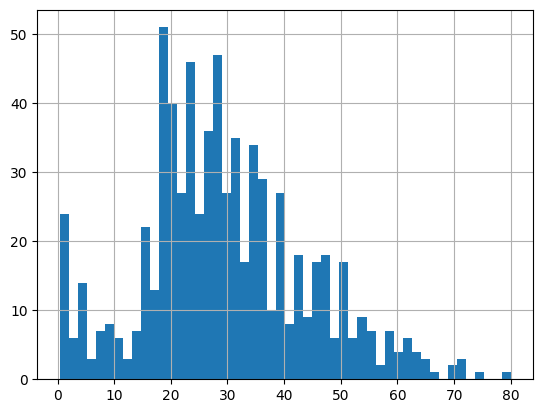

In [ ]:
# we cannot drop Age feature, which does not have as many as missing values as Cabin
df['Age'].hist(bins=50)

In [ ]:
df['Age'].describe()

,Age
count,712.000000
mean,29.642093
std,14.492933
min,0.420000
25%,20.000000
50%,28.000000
75%,38.000000
max,80.000000


In [ ]:
df['Age'].head(10)

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
5,NaN
6,54.0
7,2.0
8,27.0
9,14.0


In [ ]:
# method 1: fill the missing values with median using fillna()
# note that I don't use inplace=True because I want to demonstrate another method
median = df['Age'].median()
df_fill_median = df['Age'].fillna(median)
df_fill_median.head(10)

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
5,28.0
6,54.0
7,2.0
8,27.0
9,14.0


In [ ]:
# method 2: fill the missing values with median using Scikit-Learn SimpleImputer
# this approach can do imputation for all numerical attributes all at once
from sklearn.impute import SimpleImputer
median_imputer = SimpleImputer(strategy='median')

# select only numerical attributes for Imputer
# NOTE: Technically, Pclass (Ticket class with values 1, 2, or 3) is a categorical attribute.
# we treat Pclass as a numerical attribute here to keep it simple.
df_num = df.select_dtypes(include=['int64','float64'])

# the following computes median for each attribute and stores the result in the built-in statistics_ variable
df_num_fill_median = median_imputer.fit_transform(df_num)
median_imputer.statistics_  # same result as df_num.median().values

array([ 0.    ,  3.    , 28.    ,  0.    ,  0.    , 14.4542])

In [ ]:
df_num.median().values

array([ 0.    ,  3.    , 28.    ,  0.    ,  0.    , 14.4542])

In [ ]:
# imputer returns a numpy array
df_num_fill_median

array([[ 0.    ,  3.    , 22.    ,  1.    ,  0.    ,  7.25  ],
       [ 1.    ,  1.    , 38.    ,  1.    ,  0.    , 71.2833],
       [ 1.    ,  3.    , 26.    ,  0.    ,  0.    ,  7.925 ],
       ...,
       [ 0.    ,  3.    , 28.    ,  1.    ,  2.    , 23.45  ],
       [ 1.    ,  1.    , 26.    ,  0.    ,  0.    , 30.    ],
       [ 0.    ,  3.    , 32.    ,  0.    ,  0.    ,  7.75  ]])

In [ ]:
# change a numpy array to a DataFrame
df_num_fill_median = pd.DataFrame(df_num_fill_median, columns=df_num.columns)
df_num_fill_median.isnull().sum()  # no missing values

,0
Survived,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0


## Processing the Target Column

Save the target column and drop it from the training set. Since the target column has no missing values now and we normally don't need to encode the target column (even if it has categorical values), let's save it and then drop it from the training set.

In [ ]:
# set the target
y = df_num_fill_median['Survived']
df_num_fill_median.drop(['Survived'], axis=1, inplace=True)
df_num_fill_median.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  889 non-null    float64
 1   Age     889 non-null    float64
 2   SibSp   889 non-null    float64
 3   Parch   889 non-null    float64
 4   Fare    889 non-null    float64
dtypes: float64(5)
memory usage: 34.9 KB


In [ ]:
df_num_fill_median.describe()

,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000
mean,2.311586,29.315152,0.524184,0.382452,32.096681
std,0.834700,12.984932,1.103705,0.806761,49.697504
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.895800
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,35.000000,1.000000,0.000000,31.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200


Note that these numerical variables have very different distributions.

In general, many learning algorithms benefit from standardization of the data set.

There are different methods for standardization/scaling/normalization of data.

For instance, we can scale features to lie between a given minimum and maximum value, often between zero and one.

In [ ]:
#Make sure the numeric variables are at the same scale
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
df_num_fill_median_scaled = min_max_scaler.fit_transform(df_num_fill_median)

In [ ]:
df_num_fill_median_scaled

array([[1.        , 0.27117366, 0.125     , 0.        , 0.01415106],
       [0.        , 0.4722292 , 0.125     , 0.        , 0.13913574],
       [1.        , 0.32143755, 0.        , 0.        , 0.01546857],
       ...,
       [1.        , 0.34656949, 0.125     , 0.33333333, 0.04577135],
       [0.        , 0.32143755, 0.        , 0.        , 0.0585561 ],
       [1.        , 0.39683338, 0.        , 0.        , 0.01512699]])

In [ ]:
# change df_num_fill_median_scaled into dataframe
df_num_processed = pd.DataFrame(df_num_fill_median_scaled, columns=df_num_fill_median.columns)
df_num_processed

,Pclass,Age,SibSp,Parch,Fare
0,1.0,0.271174,0.125,0.000000,0.014151
1,0.0,0.472229,0.125,0.000000,0.139136
2,1.0,0.321438,0.000,0.000000,0.015469
3,0.0,0.434531,0.125,0.000000,0.103644
4,1.0,0.434531,0.000,0.000000,0.015713
...,...,...,...,...,...
884,0.5,0.334004,0.000,0.000000,0.025374
885,0.0,0.233476,0.000,0.000000,0.058556
886,1.0,0.346569,0.125,0.333333,0.045771
887,0.0,0.321438,0.000,0.000000,0.058556


In [ ]:
df_num_processed.describe()

,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.655793,0.363096,0.065523,0.063742,0.062649
std,0.417350,0.163168,0.137963,0.134460,0.097003
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,0.271174,0.000000,0.000000,0.015412
50%,1.000000,0.346569,0.000000,0.000000,0.028213
75%,1.000000,0.434531,0.125000,0.000000,0.060508
max,1.000000,1.000000,1.000000,1.000000,1.000000


## Processing Categorical Variables

So far, we have only included numerical variables in the model. Next, we will handle categorical variables.

In [ ]:
# get categorical attributes
df_cat = df.select_dtypes(['object'])
df_cat.head()

,Sex,Embarked
0,male,S
1,female,C
2,female,S
3,female,S
4,male,S


In [ ]:
df_cat.describe()

,Sex,Embarked
count,889,889
unique,2,3
top,male,S
freq,577,644


In [ ]:
# encode categorical values to integers
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
df_cat_ordinal = ordinal_encoder.fit_transform(df_cat)
# categories are listed in order ['female', 'male']-> 0, 1; ['C', 'Q', 'S']-> 0, 1, 2
ordinal_encoder.categories_

[array(['female', 'male'], dtype=object), array(['C', 'Q', 'S'], dtype=object)]

In [ ]:
# encoder returns a numpy array
df_cat_ordinal

array([[1., 2.],
       [0., 0.],
       [0., 2.],
       ...,
       [0., 2.],
       [1., 0.],
       [1., 1.]])

In [ ]:
# change df_cat_ordinal into dataframe
df_cat_ordinal = pd.DataFrame(df_cat_ordinal, columns=df_cat.columns)
df_cat_ordinal

,Sex,Embarked
0,1.0,2.0
1,0.0,0.0
2,0.0,2.0
3,0.0,2.0
4,1.0,2.0
...,...,...
884,1.0,2.0
885,0.0,2.0
886,0.0,2.0
887,1.0,0.0


In [ ]:
# the same cat_encoder can be used to encode new data
new_data = [['male', 'S']]
new_data_encoded = ordinal_encoder.transform(new_data)
print(new_data_encoded)

[[1. 2.]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


## Build the model

Now we can prepare for the final train dataset and build the model:

- `df_num_processed`: df_num with missing values filled using median and scaled
- `df_cat_ordinal`: df_cat encoded using Ordinal Encoder

To use both numerical and categorical variables to build a classifier, we need to prepare the final training dataset by combining them.

In [ ]:
# training dataset using ordinal encoder
titanic_train_encoded = pd.concat([df_num_processed, df_cat_ordinal], axis=1)
titanic_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    889 non-null    float64
 1   Age       889 non-null    float64
 2   SibSp     889 non-null    float64
 3   Parch     889 non-null    float64
 4   Fare      889 non-null    float64
 5   Sex       889 non-null    float64
 6   Embarked  889 non-null    float64
dtypes: float64(7)
memory usage: 48.7 KB


In [ ]:
# train a DT model using titanic_train_encoded
from sklearn.tree import DecisionTreeClassifier
tree_clf1 = DecisionTreeClassifier(criterion='entropy', max_depth=3)
tree_clf1.fit(titanic_train_encoded, y)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

## Make Predictions

When we train tree_clf1 above, titanic_train_encoded is the input dataframe we used.

When we make predictions, the input dataframe we feed into the model **MUST** match the structure (the number of columns with specific order) of titanic_train_encoded.

In [ ]:
df_test = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/titanic_test.csv')
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [ ]:
# save PassengerId column for submission
df_test_id = df_test['PassengerId']

In [ ]:
df_test_id.head()

,PassengerId
0,892
1,893
2,894
3,895
4,896


In [ ]:
# we dropped PassengerId, Name, Cabin, Ticket when training the model
# so we should drop those columns for prediction
df_test.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       332 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      417 non-null    float64
 6   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 23.0+ KB


In [ ]:
# we also need to handle missing values for the testing set
df_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,86
SibSp,0
Parch,0
Fare,1
Embarked,0


In [ ]:
# we use SimpleImputer to fill missing values in Age and Fare using median
median_imputer = SimpleImputer(strategy='median')

# select only numerical attributes for Imputer
df_test_num = df_test.select_dtypes(include=['int64','float64'])

# the following computes median for each attributes and store the result in statistics_ variable
df_test_num_fill_median = median_imputer.fit_transform(df_test_num)

# convert df_test_num_fill_mean to dataframe
df_test_num_fill_median = pd.DataFrame(df_test_num_fill_median, columns=df_test_num.columns)
df_test_num_fill_median.isnull().sum()  # no missing values

,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0


In [ ]:
# test numerical dataframe shape is 418x5
df_test_num_fill_median.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  418 non-null    float64
 1   Age     418 non-null    float64
 2   SibSp   418 non-null    float64
 3   Parch   418 non-null    float64
 4   Fare    418 non-null    float64
dtypes: float64(5)
memory usage: 16.5 KB


In [ ]:
# Check the distribution of df_test_num_fill_median
df_test_num_fill_median.describe()

,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000
mean,2.265550,29.599282,0.447368,0.392344,35.576535
std,0.841838,12.703770,0.896760,0.981429,55.850103
min,1.000000,0.170000,0.000000,0.000000,0.000000
25%,1.000000,23.000000,0.000000,0.000000,7.895800
50%,3.000000,27.000000,0.000000,0.000000,14.454200
75%,3.000000,35.750000,1.000000,0.000000,31.471875
max,3.000000,76.000000,8.000000,9.000000,512.329200


In [ ]:
# Since the training set is scaled, we must use the same scaler for the test set too.
# Important!!! Use .transform(), not .fit_transform()
df_test_num_fill_median_scaled = min_max_scaler.transform(df_test_num_fill_median)
df_test_num_fill_median_scaled

array([[1.        , 0.4282483 , 0.        , 0.        , 0.01528158],
       [1.        , 0.58532295, 0.125     , 0.        , 0.01366309],
       [0.5       , 0.77381252, 0.        , 0.        , 0.01890874],
       ...,
       [1.        , 0.47851219, 0.        , 0.        , 0.01415106],
       [1.        , 0.33400352, 0.        , 0.        , 0.01571255],
       [1.        , 0.33400352, 0.125     , 0.16666667, 0.0436405 ]])

In [ ]:
# change df_test_num_fill_median_scaled into dataframe
df_test_num_processed = pd.DataFrame(df_test_num_fill_median_scaled, columns=df_test_num_fill_median.columns)
df_test_num_processed

,Pclass,Age,SibSp,Parch,Fare
0,1.0,0.428248,0.000,0.000000,0.015282
1,1.0,0.585323,0.125,0.000000,0.013663
2,0.5,0.773813,0.000,0.000000,0.018909
3,1.0,0.334004,0.000,0.000000,0.016908
4,1.0,0.271174,0.125,0.166667,0.023984
...,...,...,...,...,...
413,1.0,0.334004,0.000,0.000000,0.015713
414,0.0,0.484795,0.000,0.000000,0.212559
415,1.0,0.478512,0.000,0.000000,0.014151
416,1.0,0.334004,0.000,0.000000,0.015713


In [ ]:
# select only categorical attributes for Encoder
df_test_cat = df_test.select_dtypes(include=['object'])
df_test_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sex       418 non-null    object
 1   Embarked  418 non-null    object
dtypes: object(2)
memory usage: 6.7+ KB


In [ ]:
df_test_cat.head()

,Sex,Embarked
0,male,Q
1,female,S
2,male,Q
3,male,S
4,female,S


In [ ]:
# You must encode the test categorical dataframe
# using the Ordinal Encoder we created for the training set
# DO NOT create a new encoder!!!

df_test_cat_ordinal = ordinal_encoder.transform(df_test_cat)

# convert df_test_cat_ordinal to dataframe
df_test_cat_ordinal = pd.DataFrame(df_test_cat_ordinal, columns=df_test_cat.columns)

In [ ]:
df_test_cat_ordinal.head()

,Sex,Embarked
0,1.0,1.0
1,0.0,2.0
2,1.0,1.0
3,1.0,2.0
4,0.0,2.0


In [ ]:
# combine the dataframes as the test input dataframe
titanic_test_encoded = pd.concat([df_test_num_processed, df_test_cat_ordinal], axis=1)
titanic_test_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    float64
 1   Age       418 non-null    float64
 2   SibSp     418 non-null    float64
 3   Parch     418 non-null    float64
 4   Fare      418 non-null    float64
 5   Sex       418 non-null    float64
 6   Embarked  418 non-null    float64
dtypes: float64(7)
memory usage: 23.0 KB


In [ ]:
# the column array for the testing input dataframe using ordinal encoding
titanic_test_encoded.columns.values

array(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked'],
      dtype=object)

In [ ]:
# the column array for the training input dataframe using ordinal encoding
titanic_train_encoded.columns.values

array(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked'],
      dtype=object)

In [ ]:
titanic_test_encoded.head()

,Pclass,Age,SibSp,Parch,Fare,Sex,Embarked
0,1.0,0.428248,0.000,0.000000,0.015282,1.0,1.0
1,1.0,0.585323,0.125,0.000000,0.013663,0.0,2.0
2,0.5,0.773813,0.000,0.000000,0.018909,1.0,1.0
3,1.0,0.334004,0.000,0.000000,0.016908,1.0,2.0
4,1.0,0.271174,0.125,0.166667,0.023984,0.0,2.0


In [ ]:
# make prediction using the first tree
y_hat = tree_clf1.predict(titanic_test_encoded)
y_hat.shape

(418,)

In [ ]:
# Note, the numbers here are float numbers with decimal, we need to convert them to integer
# if you don't do this, your score on Kaggle will be 0
y_hat

array([0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
       0., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
       0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0.,
       1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1.,
       0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 0., 1.,
       0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1.,
       0., 1., 0., 1., 1.

In [ ]:
y_hat = y_hat.astype(int)
y_hat

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
# make the dataframe for submission by combining two columns
tree1_ordinal_submit = pd.DataFrame({
    'PassengerId': df_test_id,
    'Survived': y_hat,
})

In [ ]:
tree1_ordinal_submit.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [ ]:
# save the resulting dataframe as a csv file for Kaggle submission
tree1_ordinal_submit.to_csv(f'{output_dir}/tree_ordinal_submit.csv', index=False)

## Simplify Preprocessing with a Pipeline

The manual steps above work, but we had to repeat the same preprocessing steps for the test set. A pipeline lets us fit the preprocessing steps once on the training set and reuse them automatically for the test set.

This version still uses ordinal encoding for categorical variables.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Prepare the training inputs and target from the cleaned training dataframe
X_pipeline = df.drop('Survived', axis=1)
y_pipeline = df['Survived']

# Define the numerical and categorical columns once
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Sex', 'Embarked']

# Numerical columns: fill missing values, then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Categorical columns: fill missing values, then use ordinal encoding
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))  # encode unseen test categories as -1
])

preprocess = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

tree_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', DecisionTreeClassifier(criterion='entropy', max_depth=3))
])

In [ ]:
# Fit the full pipeline once on the training set
tree_pipeline.fit(X_pipeline, y_pipeline)

In [ ]:
# Predict directly from the test dataframe
# The pipeline applies the same imputer, scaler, and ordinal encoder learned from training data
y_hat_pipeline = tree_pipeline.predict(df_test).astype(int)
y_hat_pipeline.shape

In [ ]:
tree_pipeline_submit = pd.DataFrame({
    'PassengerId': df_test_id,
    'Survived': y_hat_pipeline,
})

tree_pipeline_submit.head()

In [ ]:
# save the resulting dataframe as a csv file for Kaggle submission
tree_pipeline_submit.to_csv(f'{output_dir}/tree_pipeline_ordinal_submit.csv', index=False)

## Let's pause here and review our data processing method.

**Is this ordinal encoder appropriate for encoding these two variables? Why or why not?**

In [ ]:
# Using one-hot encoding
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder()
df_cat_onehot = onehot_encoder.fit_transform(df_cat)

onehot_encoder.categories_

[array(['female', 'male'], dtype=object), array(['C', 'Q', 'S'], dtype=object)]

In [ ]:
column_names = onehot_encoder.get_feature_names_out()
column_names

array(['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype=object)

In [ ]:
# Take a look at df_cat_onehot
df_cat_onehot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1778 stored elements and shape (889, 5)>

In [ ]:
# onehot encoder returns a sparse matrix and we must convert that to a numpy array
# This step is different from ordinal encoding
df_cat_onehot = df_cat_onehot.toarray()

In [ ]:
# change df_cat_onehot to a Dataframe by adding the column names
df_cat_onehot = pd.DataFrame(df_cat_onehot, columns=column_names)
df_cat_onehot.head()

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [ ]:
# the same onehot_encoder can be used to encode new data
new_data1 = [['male', 'S']]
new_data1_encoded = onehot_encoder.transform(new_data1)
print(new_data1_encoded.toarray())

[[0. 1. 0. 0. 1.]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


## Assignment

Now, we have these two dataframes:  
- `df_num_processed`: df_num with missing values filled using median and scaled
- `df_cat_onehot`: df_cat encoded using OneHot Encoder

Following the same process above, you need to do the following:
- Combine the two dataframes to make a new training set.
- Use the training set to build a new decision tree "tree_clf2".
- Apply "tree_clf2" to the test set with the two categorical variables 'Sex' and 'Embarked' encoded by the 'onehot_encoder'.
- Prepare the prediction results in the right format: ['PassengerId', 'Survived']
- Name the output file "tree_onehot_submit.csv" for submission

**Note: You may do this in the hard way (step by step) or the easy way (modifying the pipeline).**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

# Prepare the training inputs and target from the cleaned training dataframe
# Using the original 'df' as the starting point for the pipeline, as it handles all preprocessing internally.
X_pipeline_onehot = df.drop('Survived', axis=1)
y_pipeline_onehot = df['Survived']

# Define the numerical and categorical columns once
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Sex', 'Embarked']

# Numerical columns: fill missing values, then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Categorical columns: fill missing values, then use one-hot encoding
cat_pipeline_onehot = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')) # handle unseen test categories by ignoring them
])

# Create a ColumnTransformer to apply different transformations to different columns
preprocess_onehot = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline_onehot, cat_cols)
])

# Create the full pipeline with preprocessing and the Decision Tree model
tree_pipeline_onehot = Pipeline([
    ('preprocess', preprocess_onehot),
    ('model', DecisionTreeClassifier(criterion='entropy', max_depth=3))
])

# Fit the full pipeline once on the training set
tree_pipeline_onehot.fit(X_pipeline_onehot, y_pipeline_onehot)

# Predict directly from the test dataframe (df_test was loaded previously)
# The pipeline applies the same imputer, scaler, and one-hot encoder learned from training data
y_hat_onehot = tree_pipeline_onehot.predict(df_test).astype(int)

# Create the submission DataFrame
tree_onehot_submit = pd.DataFrame({
    'PassengerId': df_test_id, # df_test_id was saved previously
    'Survived': y_hat_onehot,
})

# Display the head of the submission file
print(tree_onehot_submit.head())

# Save the resulting dataframe as a csv file for Kaggle submission
tree_onehot_submit.to_csv(f'{output_dir}/tree_onehot_submit.csv', index=False)
print(f'Submission file saved to: {output_dir}/tree_onehot_submit.csv')

   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
Submission file saved to: /content/drive/My Drive/Colab Notebooks/output//tree_onehot_submit.csv
